# Phase 3 — Improved CNN: Regularization & Hyperparameter Tuning

**Goal:** Start from the Phase 2 baseline and improve it systematically.  
No pretrained models. We add data augmentation, BatchNorm, and Dropout — and run **5 experiments** to find the best configuration.

**Key fixes vs Phase 2:**
- **Random validation split** via `image_dataset_from_directory(seed=42)` — fixes the alphabetical-order gap
- **Data augmentation** on train set (flip, rotate, zoom, shift, brightness)
- **BatchNorm** and **Dropout** as regularization options
- **ReduceLROnPlateau** and **EarlyStopping** for stable convergence

**Phase 2 reference:** test acc = 79.53%, macro F1 = 80.19%, macro AUC = 95.52%

In [1]:
import os, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, optimizers
from tensorflow.keras.callbacks import (
    ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.dpi']        = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

print(f'TensorFlow {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

I0000 00:00:1779897652.007835   14622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779897652.065096   14622 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779897652.979287   14622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
if Path.cwd().name == 'notebooks':
    os.chdir('..')

DATA_ROOT  = Path('/home/arman/blood_cell_data')   # WSL native ext4 — fast I/O
TRAIN_DIR  = DATA_ROOT / 'TRAIN'
TEST_DIR   = DATA_ROOT / 'TEST'
FIGS       = Path('outputs/figures')
LOGS       = Path('outputs/logs')
MODELS_DIR = Path('saved_models')

for d in [FIGS, LOGS, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASSES  = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
COLORS   = ['#4FA3D1', '#5DBB8A', '#E8A838', '#D15F4F']
IMG_SIZE = (128, 128)
AUTOTUNE = tf.data.AUTOTUNE

# Phase 2 reference scores (for final comparison)
PHASE2 = dict(test_acc=0.7953, prec=0.8178, rec=0.7955, f1=0.8019, auc=0.9552)

print('Paths OK')
print(f'TRAIN_DIR = {TRAIN_DIR}  exists={TRAIN_DIR.exists()}')
print(f'TEST_DIR  = {TEST_DIR}   exists={TEST_DIR.exists()}')
print(f'IMG_SIZE  = {IMG_SIZE}')

Paths OK
TRAIN_DIR = /home/arman/blood_cell_data/TRAIN  exists=True
TEST_DIR  = /home/arman/blood_cell_data/TEST   exists=True
IMG_SIZE  = (128, 128)


## 1. Data Pipeline

`image_dataset_from_directory` with `seed=42` shuffles the file list before splitting, giving a **truly random** 80/20 split — unlike Phase 2's `ImageDataGenerator(validation_split=...)` which always took the last 20% alphabetically.

Augmentation is applied **only on the training set** at runtime (not cached), so each epoch sees different random transforms.

In [3]:
# ---- Augmentation pipeline (Keras layers — runs on GPU) ----
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(15 / 360),        # +-15 degrees
    layers.RandomZoom(0.10),                # +-10% zoom
    layers.RandomTranslation(0.10, 0.10),   # +-10% shift
    layers.RandomBrightness(0.20),          # +-20% brightness
], name='augmentation')

rescaling = layers.Rescaling(1.0 / 255)


def build_datasets(batch_size=32, augment=True):
    """Return (train_ds, val_ds, test_ds) with a truly random 80/20 split.

    seed=42 with shuffle=True shuffles the file list before splitting, so
    both train and val have a balanced class distribution.
    """
    common = dict(seed=42, image_size=IMG_SIZE, label_mode='int')

    train_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, validation_split=0.2, subset='training',
        batch_size=batch_size, shuffle=True, **common)

    val_ds = tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR, validation_split=0.2, subset='validation',
        batch_size=batch_size, shuffle=False, **common)

    test_ds = tf.keras.utils.image_dataset_from_directory(
        TEST_DIR, batch_size=batch_size, shuffle=False,
        image_size=IMG_SIZE, label_mode='int')

    def prep_train(x, y):
        x = tf.cast(x, tf.float32)
        if augment:
            x = data_augmentation(x, training=True)
        return rescaling(x), y

    def prep_eval(x, y):
        return rescaling(tf.cast(x, tf.float32)), y

    train_ds = train_ds.map(prep_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    val_ds   = val_ds.map(prep_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    test_ds  = test_ds.map(prep_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds


# Verify
train_ds, val_ds, test_ds = build_datasets(batch_size=32, augment=True)
print(f'Train batches : {len(train_ds)}')
print(f'Val   batches : {len(val_ds)}')
print(f'Test  batches : {len(test_ds)}')

for xb, yb in train_ds.take(1):
    print(f'\nBatch shape  : {xb.shape}  labels: {yb.shape}')
    print(f'Pixel range  : [{xb.numpy().min():.3f}, {xb.numpy().max():.3f}]')
    print(f'Label sample : {yb.numpy()[:8]}')

Found 9957 files belonging to 4 classes.
Using 7966 files for training.


I0000 00:00:1779897653.754913   14622 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5520 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Train batches : 249
Val   batches : 63
Test  batches : 78

Batch shape  : (32, 128, 128, 3)  labels: (32,)
Pixel range  : [0.000, 1.000]
Label sample : [2 2 3 0 2 1 1 0]


## 2. Model Architecture

Same **4-block backbone** as Phase 2 (Conv32 → Conv64 → Conv128 → Conv128 → Flatten → Dense64 → Dense4).

Two new optional components:
- **BatchNorm**: placed after `Conv2D` (no bias) and before `ReLU` — stabilises training and allows higher LR
- **Dropout**: placed before the output Dense — reduces co-adaptation between neurons

In [4]:
def build_model(use_bn=False, dropout_rate=0.0,
                num_classes=4, input_shape=(128, 128, 3)):
    """
    Phase 2 backbone with optional BatchNorm and Dropout.
    BN pattern: Conv2D (no bias) → BN → Activation(relu) → MaxPool
    """
    inp = tf.keras.Input(shape=input_shape)
    x   = inp

    for filters in [32, 64, 128, 128]:
        # Conv2D has no bias when BN is used (BN shifts take over)
        x = layers.Conv2D(filters, (3, 3), padding='same',
                          use_bias=(not use_bn))(x)
        if use_bn:
            x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D((2, 2))(x)

    x   = layers.Flatten()(x)
    x   = layers.Dense(64, activation='relu')(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    name = f'cnn_bn{int(use_bn)}_do{int(dropout_rate*10)}'
    return tf.keras.Model(inp, out, name=name)


# Preview with BN + Dropout
_m = build_model(use_bn=True, dropout_rate=0.5)
_m.summary()
print(f'\nTotal params: {_m.count_params():,}')

Model: "cnn_bn1_do5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 766,500 (2.92 MB)

 Trainable params: 765,796 (2.92 MB)

 Non-trainable params: 704 (2.75 KB)


Total params: 766,500


## 3. Hyperparameter Experiments

5 experiments — all use augmentation and LR=1e-4, varying BN, Dropout, batch size, and LR scheduling:

| # | BatchNorm | Dropout | LR | Batch | ReduceLR | EarlyStop |
|---|---|---|---|---|---|---|
| Exp 1 | No | — | 1e-4 | 32 | No | Yes (val_loss) |
| Exp 2 | No | 0.3 | 1e-4 | 32 | No | Yes (val_loss) |
| Exp 3 | Yes | 0.3 | 1e-4 | 32 | No | Yes (val_loss) |
| Exp 4 | Yes | 0.5 | 1e-4 | 32 | Yes | Yes (val_loss) |
| Exp 5 | Yes | 0.5 | 1e-4 | 64 | Yes | Yes (val_loss) |

All checkpoints and early stopping monitor **val_loss** (lower = better).  
`val_accuracy` is logged but not used for decisions — it has an XLA warm-up glitch in epoch 1.

In [5]:
results = {}   # stores history + metrics for each experiment


def run_experiment(name, use_bn, dropout_rate, lr,
                   batch_size=32, epochs=40,
                   use_reducelr=False, patience_es=10):
    print(f'\n{"="*62}')
    print(f'  {name}')
    print(f'  BN={use_bn}  Dropout={dropout_rate}  LR={lr}  '
          f'Batch={batch_size}  ReduceLR={use_reducelr}')
    print(f'{"="*62}')

    tr_ds, vl_ds, _ = build_datasets(batch_size=batch_size, augment=True)

    model = build_model(use_bn=use_bn, dropout_rate=dropout_rate)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]
    )

    cbs = [
        # Monitor val_loss (stable) — val_accuracy has an XLA warm-up glitch in epoch 1
        ModelCheckpoint(
            str(MODELS_DIR / f'{name}_best.keras'),
            monitor='val_loss', save_best_only=True,
            mode='min', verbose=0),
        CSVLogger(str(LOGS / f'{name}.csv')),
        EarlyStopping(
            monitor='val_loss', patience=patience_es,
            mode='min', restore_best_weights=True, verbose=1),
    ]
    if use_reducelr:
        cbs.append(ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=5, min_lr=1e-7, verbose=1))

    history = model.fit(
        tr_ds, epochs=epochs,
        validation_data=vl_ds,
        callbacks=cbs, verbose=1
    )

    best_val_loss = min(history.history['val_loss'])
    best_epoch    = history.history['val_loss'].index(best_val_loss) + 1
    best_val_acc  = history.history['val_accuracy'][best_epoch - 1]
    print(f'\n  Best val loss : {best_val_loss:.4f}  at epoch {best_epoch}')
    print(f'  Val acc there : {best_val_acc:.4f}')

    results[name] = {
        'use_bn': use_bn, 'dropout': dropout_rate,
        'lr': lr, 'batch': batch_size, 'reducelr': use_reducelr,
        'best_val_loss': best_val_loss,
        'best_val_acc':  best_val_acc,
        'best_epoch':    best_epoch,
        'history':       history,
        'model_file':    f'{name}_best.keras',
    }
    return history

### Experiment 1 — Augmentation only (no BN, no Dropout)

Simplest improvement over Phase 2: only data augmentation is added, everything else stays the same.

In [6]:
run_experiment(
    name='exp1_aug_only',
    use_bn=False, dropout_rate=0.0,
    lr=1e-4, batch_size=32, epochs=40,
    use_reducelr=False
)


  exp1_aug_only
  BN=False  Dropout=0.0  LR=0.0001  Batch=32  ReduceLR=False
Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Epoch 1/40


I0000 00:00:1779897657.904097   14723 service.cc:153] XLA service 0x70314c032780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779897657.904127   14723 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9 (Driver: 12.7.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779897657.954684   14723 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779897658.176374   14723 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779897658.197755   14723 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3467__.48


  3/249 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.2222 - loss: 1.3855

I0000 00:00:1779897663.928585   14723 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2494 - loss: 1.3887

I0000 00:00:1779897668.736614   14721 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3467__.48


249/249 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.2552 - loss: 1.3873 - val_accuracy: 0.9945 - val_loss: 1.3675
Epoch 2/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.2827 - loss: 1.3762 - val_accuracy: 0.1969 - val_loss: 1.4023
Epoch 3/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.3958 - loss: 1.2522 - val_accuracy: 0.4380 - val_loss: 1.1436
Epoch 4/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4897 - loss: 1.1178 - val_accuracy: 0.4410 - val_loss: 1.0988
Epoch 5/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5412 - loss: 1.0263 - val_accuracy: 0.4505 - val_loss: 1.0837
Epoch 6/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6016 - loss: 0.9171 - val_accuracy: 0.5600 - val_loss: 0.9256
Epoch 7/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6596 - loss: 0.7847 - val_accuracy: 0.7911 - val_loss: 0.7480
Epoch 8/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7041 - loss: 0.6743 - val_accuracy: 0.77

### Experiment 2 — Augmentation + Dropout(0.3)

Adds mild regularization. Dropout(0.3) means 30% of Dense units are randomly zeroed each training step.

In [7]:
run_experiment(
    name='exp2_aug_drop03',
    use_bn=False, dropout_rate=0.3,
    lr=1e-4, batch_size=32, epochs=40,
    use_reducelr=False
)


  exp2_aug_drop03
  BN=False  Dropout=0.3  LR=0.0001  Batch=32  ReduceLR=False
Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Epoch 1/40


I0000 00:00:1779897964.484302   14723 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59893__.49


246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2473 - loss: 1.3916

I0000 00:00:1779897973.484396   14721 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_59893__.49


249/249 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.2501 - loss: 1.3884 - val_accuracy: 0.0000e+00 - val_loss: 1.3934
Epoch 2/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.2572 - loss: 1.3864 - val_accuracy: 0.0000e+00 - val_loss: 1.3935
Epoch 3/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.2720 - loss: 1.3835 - val_accuracy: 0.0216 - val_loss: 1.2944
Epoch 4/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.4199 - loss: 1.2291 - val_accuracy: 0.4164 - val_loss: 1.1056
Epoch 5/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.5414 - loss: 0.9940 - val_accuracy: 0.4199 - val_loss: 0.9270
Epoch 6/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6233 - loss: 0.8354 - val_accuracy: 0.6615 - val_loss: 0.8373
Epoch 7/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.6786 - loss: 0.7316 - val_accuracy: 0.5620 - val_loss: 0.7733
Epoch 8/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.7130 - loss: 0.6388 - val_accura

### Experiment 3 — Augmentation + BatchNorm + Dropout(0.3)

BatchNorm normalises each conv layer's output, allowing a higher LR (1e-3) without instability.

In [8]:
run_experiment(
    name='exp3_aug_bn_drop03',
    use_bn=True, dropout_rate=0.3,
    lr=1e-4, batch_size=32, epochs=40,
    use_reducelr=False
)


  exp3_aug_bn_drop03
  BN=True  Dropout=0.3  LR=0.0001  Batch=32  ReduceLR=False
Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Epoch 1/40


I0000 00:00:1779898282.752312   14723 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_117376__.69


246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2585 - loss: 1.5443

I0000 00:00:1779898294.545482   14720 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_117376__.69


249/249 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.2551 - loss: 1.4267 - val_accuracy: 0.8900 - val_loss: 1.3871
Epoch 2/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.2478 - loss: 1.3864 - val_accuracy: 0.0010 - val_loss: 1.3856
Epoch 3/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.2545 - loss: 1.3869 - val_accuracy: 0.0010 - val_loss: 1.3855
Epoch 4/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2528 - loss: 1.3863 - val_accuracy: 0.0015 - val_loss: 1.3855
Epoch 5/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.2527 - loss: 1.3863 - val_accuracy: 5.0226e-04 - val_loss: 1.3853
Epoch 6/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.2526 - loss: 1.3864 - val_accuracy: 5.0226e-04 - val_loss: 1.3856
Epoch 7/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2528 - loss: 1.3863 - val_accuracy: 5.0226e-04 - val_loss: 1.3854
Epoch 8/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2533 - loss: 1.3866 - val_ac

### Experiment 4 — Augmentation + BatchNorm + Dropout(0.5) + ReduceLROnPlateau

Heavier dropout and adaptive learning rate: LR drops by ×0.3 when val_loss plateaus for 5 epochs.

In [9]:
run_experiment(
    name='exp4_aug_bn_drop05_reducelr',
    use_bn=True, dropout_rate=0.5,
    lr=1e-4, batch_size=32, epochs=50,
    use_reducelr=True
)


  exp4_aug_bn_drop05_reducelr
  BN=True  Dropout=0.5  LR=0.0001  Batch=32  ReduceLR=True
Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Epoch 1/50


I0000 00:00:1779898450.340078   14720 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_147107__.69


246/249 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2599 - loss: 1.5309

I0000 00:00:1779898460.282512   14720 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_147107__.69


249/249 ━━━━━━━━━━━━━━━━━━━━ 17s 51ms/step - accuracy: 0.2553 - loss: 1.4194 - val_accuracy: 0.1502 - val_loss: 1.3879 - learning_rate: 1.0000e-04
Epoch 2/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.2528 - loss: 1.3868 - val_accuracy: 0.0000e+00 - val_loss: 1.3864 - learning_rate: 1.0000e-04
Epoch 3/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.2528 - loss: 1.3863 - val_accuracy: 0.0000e+00 - val_loss: 1.3864 - learning_rate: 1.0000e-04
Epoch 4/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.2528 - loss: 1.3863 - val_accuracy: 0.0000e+00 - val_loss: 1.3864 - learning_rate: 1.0000e-04
Epoch 5/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.2530 - loss: 1.3863 - val_accuracy: 0.0000e+00 - val_loss: 1.3861 - learning_rate: 1.0000e-04
Epoch 6/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.2536 - loss: 1.3862 - val_accuracy: 0.0000e+00 - val_loss: 1.3865 - learning_rate: 1.0000e-04
Epoch 7/50
249/249 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/

### Experiment 5 — Augmentation + BatchNorm + Dropout(0.5) + ReduceLR + Batch 64

Larger batch size (64) — larger batches give smoother gradient estimates and can help with BN statistics.

In [10]:
run_experiment(
    name='exp5_aug_bn_drop05_b64',
    use_bn=True, dropout_rate=0.5,
    lr=1e-4, batch_size=64, epochs=50,
    use_reducelr=True
)


  exp5_aug_bn_drop05_b64
  BN=True  Dropout=0.5  LR=0.0001  Batch=64  ReduceLR=True
Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.
Epoch 1/50


I0000 00:00:1779898619.887254   14721 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176763__.69


123/125 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2578 - loss: 1.5170

I0000 00:00:1779898638.365219   14723 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_176763__.69


125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 111ms/step - accuracy: 0.2524 - loss: 1.4197 - val_accuracy: 0.1100 - val_loss: 1.3860 - learning_rate: 1.0000e-04
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.2470 - loss: 1.3856 - val_accuracy: 0.0000e+00 - val_loss: 1.3866 - learning_rate: 1.0000e-04
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.2735 - loss: 1.3767 - val_accuracy: 0.0035 - val_loss: 1.3390 - learning_rate: 1.0000e-04
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.2968 - loss: 1.3577 - val_accuracy: 0.0512 - val_loss: 1.1767 - learning_rate: 1.0000e-04
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.3130 - loss: 1.3455 - val_accuracy: 0.0156 - val_loss: 1.1272 - learning_rate: 1.0000e-04
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 55ms/step - accuracy: 0.3210 - loss: 1.3206 - val_accuracy: 0.0065 - val_loss: 1.1499 - learning_rate: 1.0000e-04
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - accuracy

## 4. Results Comparison

In [11]:
# ---- Summary table ----
rows = []
for name, r in results.items():
    rows.append({
        'Experiment'    : name,
        'BatchNorm'     : 'Yes' if r['use_bn'] else 'No',
        'Dropout'       : r['dropout'] if r['dropout'] > 0 else '—',
        'LR'            : r['lr'],
        'Batch'         : r['batch'],
        'ReduceLR'      : 'Yes' if r['reducelr'] else 'No',
        'Best Val Loss' : f"{r['best_val_loss']:.4f}",
        'Val Acc@Best'  : f"{r['best_val_acc']:.4f}",
        'Best Epoch'    : r['best_epoch'],
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

best_name = min(results, key=lambda k: results[k]['best_val_loss'])
print(f'\n>>> Best experiment : {best_name}')
print(f'    Best val loss   : {results[best_name]["best_val_loss"]:.4f}')
print(f'    Val acc there   : {results[best_name]["best_val_acc"]:.4f}')

                 Experiment BatchNorm Dropout     LR  Batch ReduceLR Best Val Loss Val Acc@Best  Best Epoch
              exp1_aug_only        No       — 0.0001     32       No        0.0816       0.9879          34
            exp2_aug_drop03        No     0.3 0.0001     32       No        0.0788       0.9859          39
         exp3_aug_bn_drop03       Yes     0.3 0.0001     32       No        1.3853       0.0005           9
exp4_aug_bn_drop05_reducelr       Yes     0.5 0.0001     32      Yes        1.3860       0.0005           9
     exp5_aug_bn_drop05_b64       Yes     0.5 0.0001     64      Yes        0.0428       0.9950          48

>>> Best experiment : exp5_aug_bn_drop05_b64
    Best val loss   : 0.0428
    Val acc there   : 0.9950


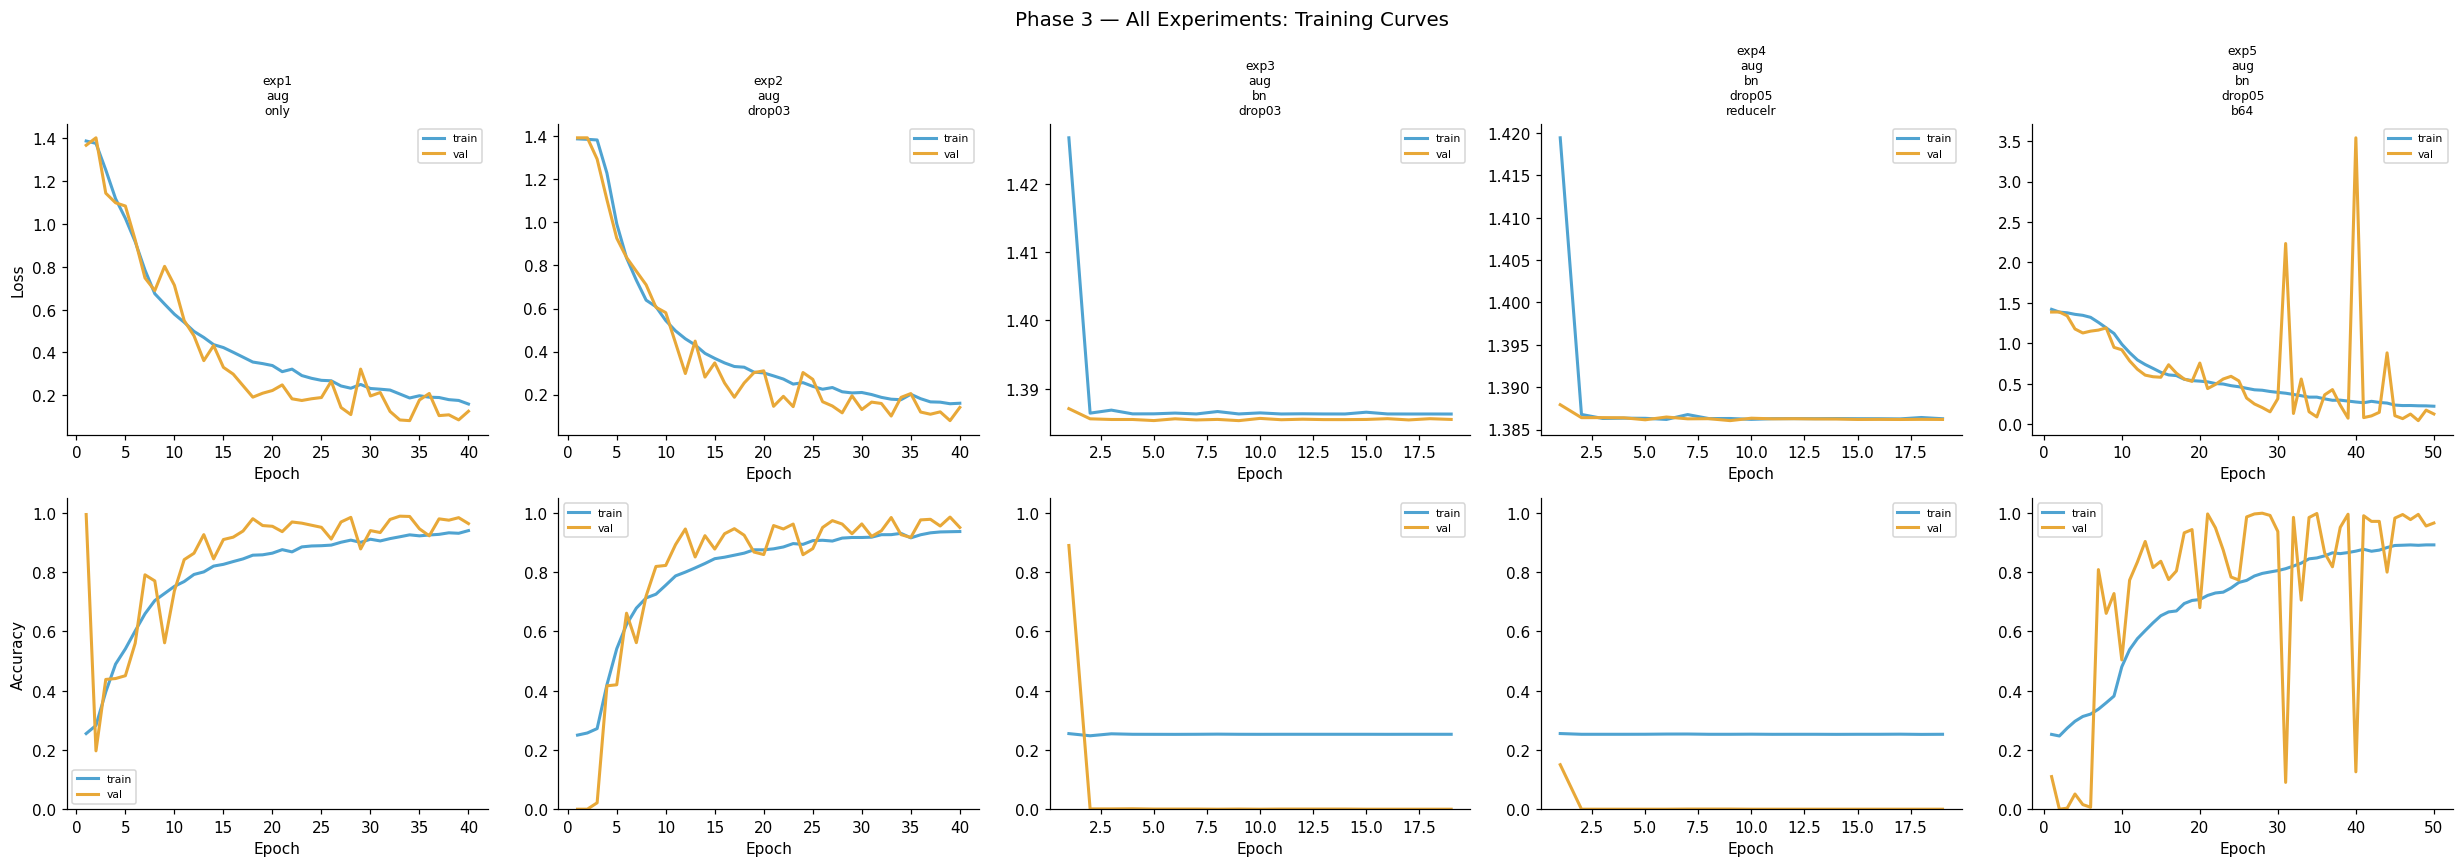

saved -> outputs/figures/phase3_01_all_training_curves.png


In [12]:
# ---- Training curves for all experiments ----
n_exp = len(results)
fig, axes = plt.subplots(2, n_exp, figsize=(4.5 * n_exp, 8))

for col, (name, r) in enumerate(results.items()):
    h  = r['history']
    ep = range(1, len(h.history['loss']) + 1)
    label = name.replace('_', '\n')

    axes[0, col].plot(ep, h.history['loss'],     color='#4FA3D1', lw=2, label='train')
    axes[0, col].plot(ep, h.history['val_loss'], color='#E8A838', lw=2, label='val')
    axes[0, col].set_title(label, fontsize=8)
    axes[0, col].set_xlabel('Epoch')
    if col == 0: axes[0, col].set_ylabel('Loss')
    axes[0, col].legend(fontsize=7)

    axes[1, col].plot(ep, h.history['accuracy'],     color='#4FA3D1', lw=2, label='train')
    axes[1, col].plot(ep, h.history['val_accuracy'], color='#E8A838', lw=2, label='val')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylim(0, 1.05)
    if col == 0: axes[1, col].set_ylabel('Accuracy')
    axes[1, col].legend(fontsize=7)

fig.suptitle('Phase 3 — All Experiments: Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / 'phase3_01_all_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase3_01_all_training_curves.png')

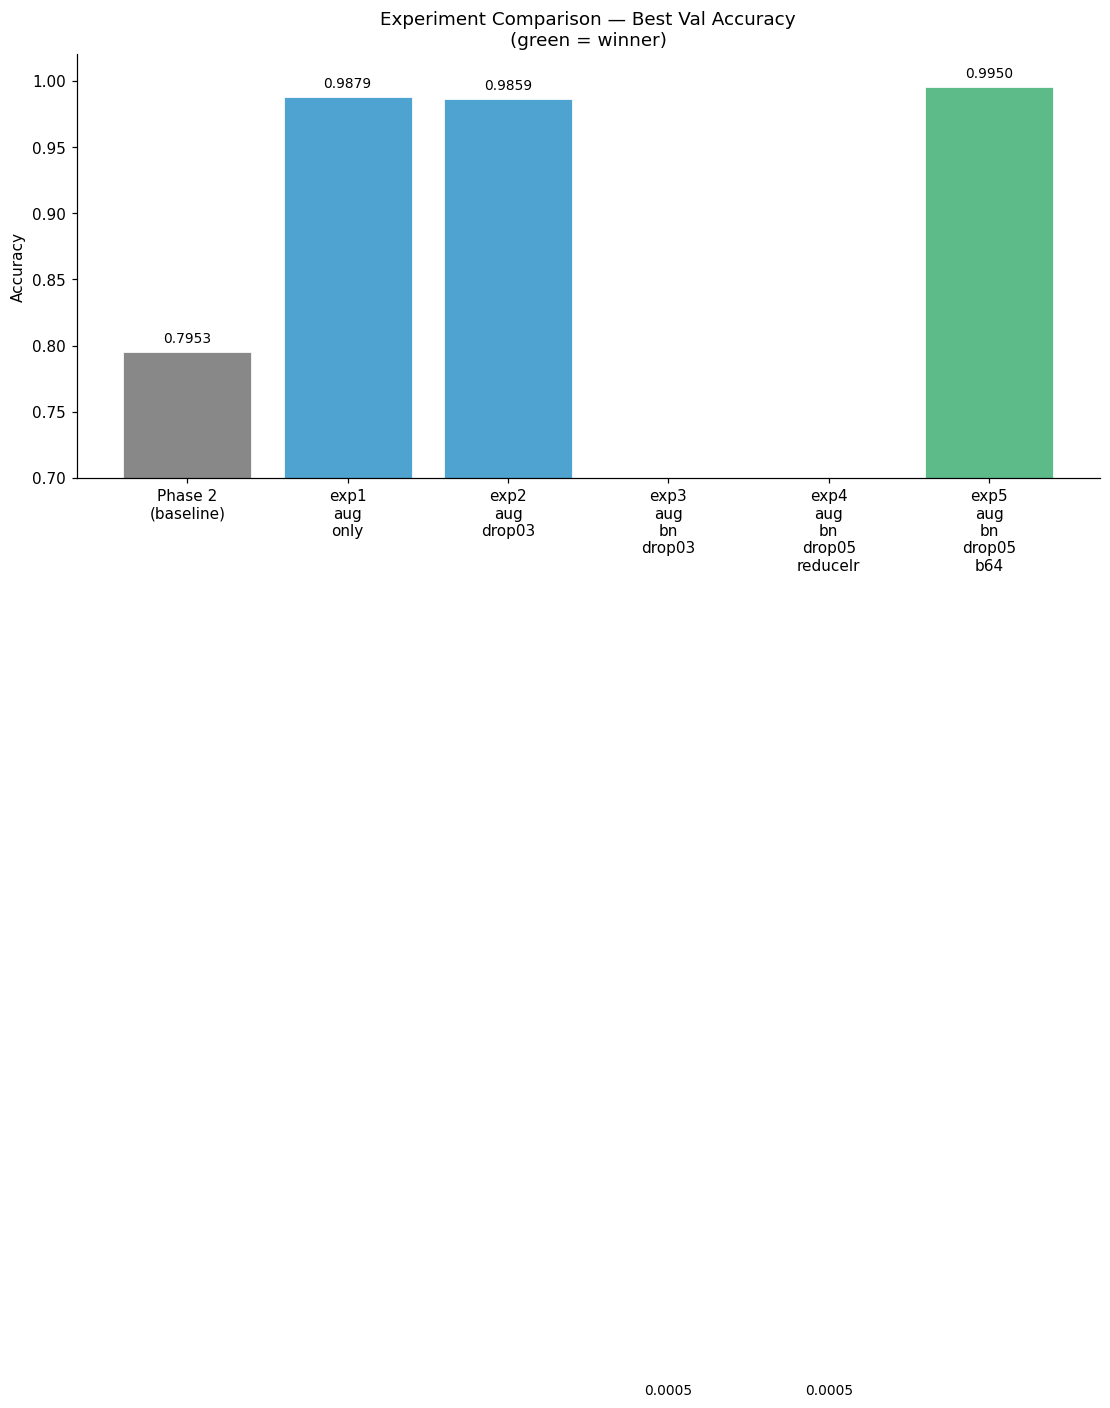

saved -> outputs/figures/phase3_02_experiment_comparison.png


In [13]:
# ---- Val accuracy bar chart (all experiments + Phase 2 baseline) ----
names    = ['Phase 2\n(baseline)'] + [n.replace('_', '\n') for n in results]
val_accs = [PHASE2['test_acc']] + [r['best_val_acc'] for r in results.values()]
bar_colors = ['#888888'] + ['#4FA3D1' if n != best_name else '#5DBB8A' for n in results]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(names, val_accs, color=bar_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Accuracy')
ax.set_title('Experiment Comparison — Best Val Accuracy\n(green = winner)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'phase3_02_experiment_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase3_02_experiment_comparison.png')

## 5. Best Model — Full TEST Evaluation

Load the best checkpoint from the winning experiment and evaluate on the held-out TEST set.

In [14]:
print(f'Best experiment : {best_name}')
print(f'Best val acc    : {results[best_name]["best_val_acc"]:.4f}')

best_model = tf.keras.models.load_model(
    MODELS_DIR / results[best_name]['model_file'])

# Collect predictions from test_ds (shuffle=False, so order is deterministic)
# Rebuild test_ds to ensure correct batch size
_, _, test_ds_eval = build_datasets(batch_size=32, augment=False)

y_true_list, y_proba_list = [], []
for x_batch, y_batch in test_ds_eval:
    y_true_list.extend(y_batch.numpy())
    y_proba_list.extend(best_model(x_batch, training=False).numpy())

y_true       = np.array(y_true_list)
y_pred_proba = np.array(y_proba_list)
y_pred       = np.argmax(y_pred_proba, axis=1)

test_loss, test_acc = best_model.evaluate(test_ds_eval, verbose=0)
print(f'\nTest loss     : {test_loss:.4f}')
print(f'Test accuracy : {test_acc:.4f}')

Best experiment : exp5_aug_bn_drop05_b64
Best val acc    : 0.9950
Found 9957 files belonging to 4 classes.
Using 7966 files for training.
Found 9957 files belonging to 4 classes.
Using 1991 files for validation.
Found 2487 files belonging to 4 classes.

Test loss     : 1.4701
Test accuracy : 0.7238


### 5.1 Classification Report

In [15]:
print(classification_report(y_true, y_pred, target_names=CLASSES))

              precision    recall  f1-score   support

  EOSINOPHIL       0.74      0.66      0.69       623
  LYMPHOCYTE       1.00      0.55      0.71       620
    MONOCYTE       0.79      0.72      0.76       620
  NEUTROPHIL       0.60      0.97      0.74       624

    accuracy                           0.73      2487
   macro avg       0.78      0.73      0.73      2487
weighted avg       0.78      0.73      0.73      2487



### 5.2 Confusion Matrix

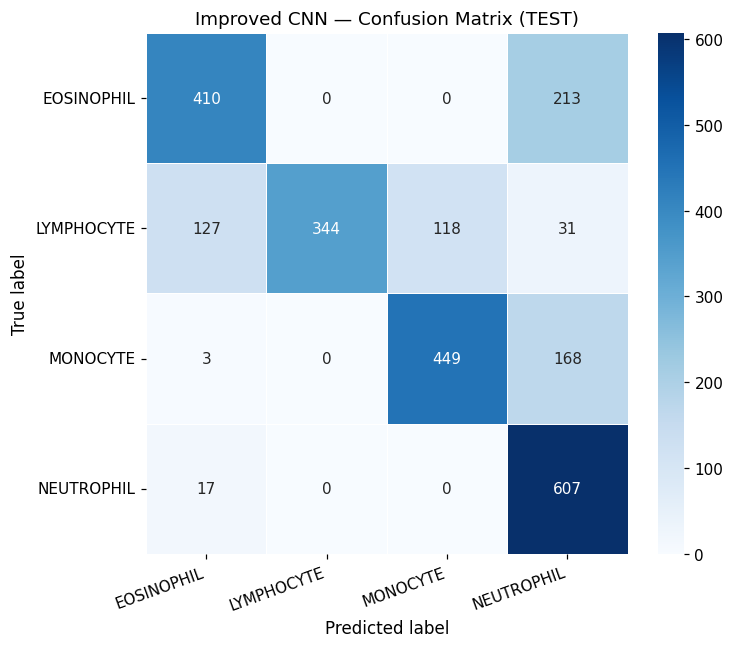

saved -> outputs/figures/phase3_03_confusion_matrix.png


In [16]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted label', fontsize=11)
ax.set_ylabel('True label',      fontsize=11)
ax.set_title(f'Improved CNN — Confusion Matrix (TEST)', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGS / 'phase3_03_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase3_03_confusion_matrix.png')

### 5.3 ROC Curves + AUC

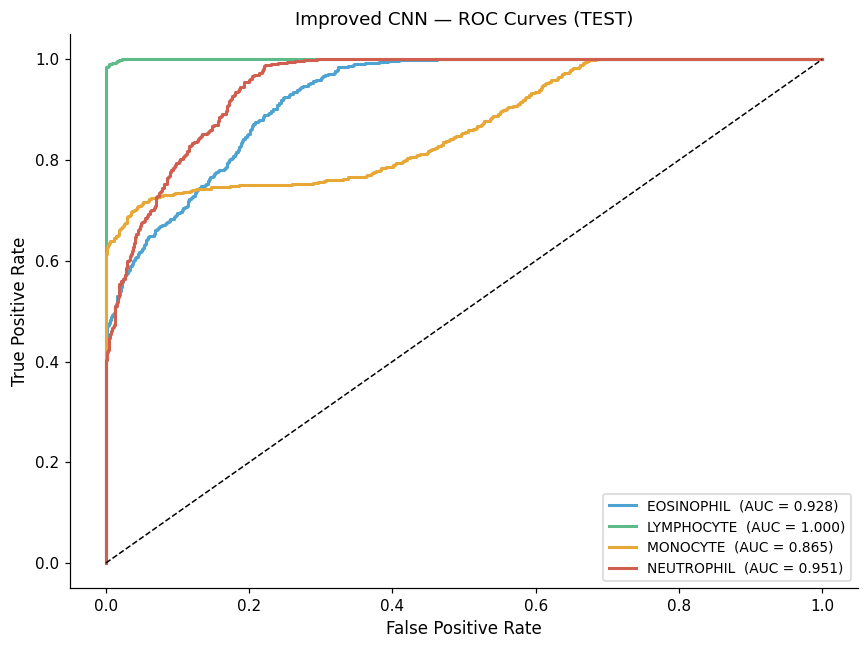

saved -> outputs/figures/phase3_04_roc_curves.png

AUC per class:
  EOSINOPHIL    : 0.9277
  LYMPHOCYTE    : 0.9998
  MONOCYTE      : 0.8650
  NEUTROPHIL    : 0.9509
  Macro avg   : 0.9359


In [17]:
y_true_bin = label_binarize(y_true, classes=list(range(len(CLASSES))))

fig, ax = plt.subplots(figsize=(8, 6))
auc_scores = {}
for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls}  (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate',  fontsize=11)
ax.set_title('Improved CNN — ROC Curves (TEST)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / 'phase3_04_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase3_04_roc_curves.png')

print('\nAUC per class:')
for cls, score in auc_scores.items():
    print(f'  {cls:<14}: {score:.4f}')
print(f'  Macro avg   : {np.mean(list(auc_scores.values())):.4f}')

### 5.4 Sample Predictions from TEST

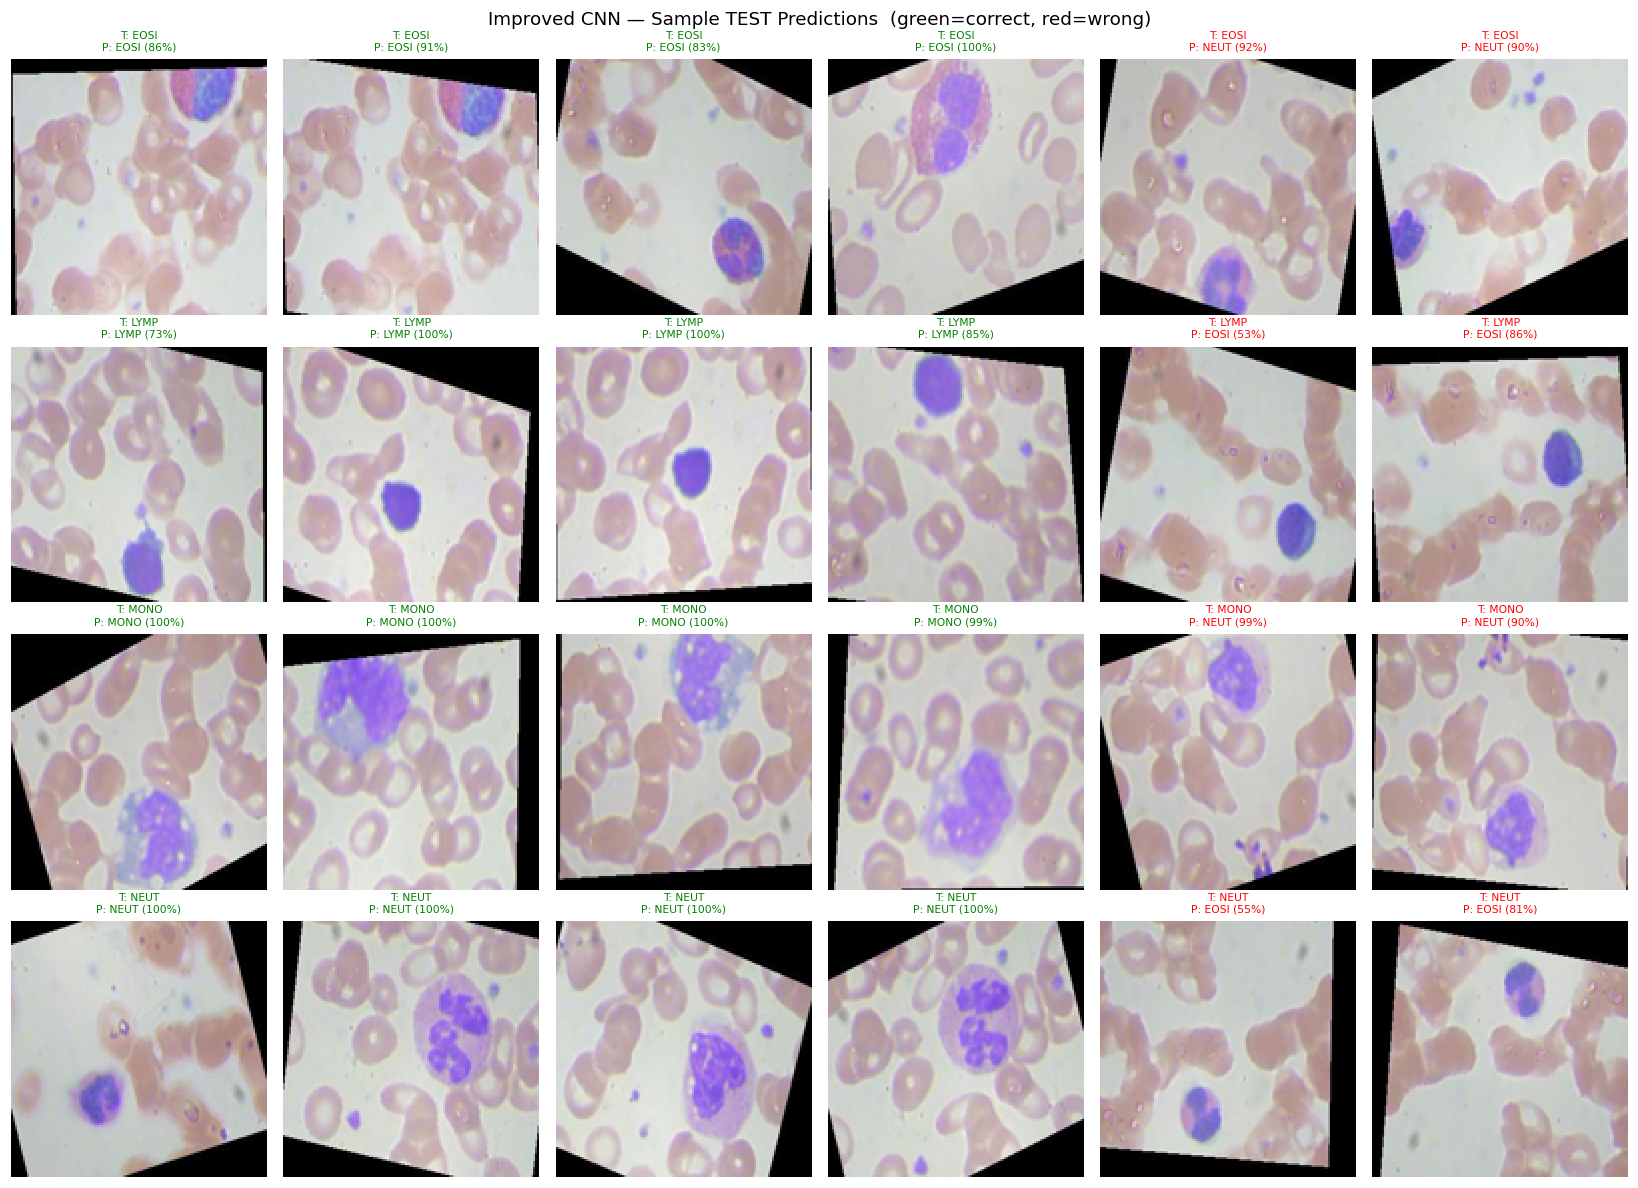

saved -> outputs/figures/phase3_05_sample_predictions.png


In [18]:
# Reconstruct test file paths in the same order as image_dataset_from_directory
# (sorted class dirs, then sorted files within each class)
test_filepaths = []
for cls in sorted([d.name for d in TEST_DIR.iterdir() if d.is_dir()]):
    cls_dir = TEST_DIR / cls
    files = sorted([f for f in cls_dir.iterdir()
                    if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    test_filepaths.extend(files)
test_filepaths = np.array(test_filepaths)

fig, axes = plt.subplots(4, 6, figsize=(15, 11))
for row, cls_idx in enumerate(range(len(CLASSES))):
    cls_mask    = (y_true == cls_idx)
    correct_idx = np.where(cls_mask & (y_pred == y_true))[0]
    wrong_idx   = np.where(cls_mask & (y_pred != y_true))[0]

    # Take up to 4 correct + up to 2 wrong, then pad with whatever is available
    chosen = list(correct_idx[:4]) + list(wrong_idx[:2])
    remaining = list(correct_idx[4:]) + list(wrong_idx[2:])
    while len(chosen) < 6 and remaining:
        chosen.append(remaining.pop(0))
    # Last resort: repeat last sample if the class has very few images
    while len(chosen) < 6 and chosen:
        chosen.append(chosen[-1])

    for col, idx in enumerate(chosen[:6]):
        img = np.array(Image.open(test_filepaths[idx]).resize((128, 128)))
        axes[row, col].imshow(img)
        t, p = CLASSES[y_true[idx]], CLASSES[y_pred[idx]]
        conf = y_pred_proba[idx][y_pred[idx]] * 100
        ok   = (y_true[idx] == y_pred[idx])
        axes[row, col].set_title(
            f'T: {t[:4]}\nP: {p[:4]} ({conf:.0f}%)',
            fontsize=7, color='green' if ok else 'red')
        axes[row, col].axis('off')

fig.suptitle('Improved CNN — Sample TEST Predictions  (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'phase3_05_sample_predictions.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase3_05_sample_predictions.png')

## 6. Full Results Summary & Comparison with Phase 2

In [19]:
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
macro_auc = np.mean(list(auc_scores.values()))

print('=' * 62)
print('  PHASE 2  vs  PHASE 3  —  TEST SET COMPARISON')
print('=' * 62)
print(f'{"Metric":<22}  {"Phase 2 (baseline)":>18}  {"Phase 3 (best)":>14}  {"Δ":>7}')
print('-' * 62)
for metric, p2_val, p3_val in [
    ('Accuracy',     PHASE2['test_acc'], test_acc),
    ('Precision',    PHASE2['prec'],     prec),
    ('Recall',       PHASE2['rec'],      rec),
    ('F1 (macro)',   PHASE2['f1'],       f1),
    ('AUC (macro)',  PHASE2['auc'],      macro_auc),
]:
    delta = p3_val - p2_val
    sign  = '+' if delta >= 0 else ''
    print(f'  {metric:<20}  {p2_val:>18.4f}  {p3_val:>14.4f}  {sign}{delta:>6.4f}')
print('=' * 62)

print(f'\nBest experiment  : {best_name}')
print(f'Test accuracy    : {test_acc:.4f}')
print(f'Improvement      : {(test_acc - PHASE2["test_acc"]) * 100:+.2f} pp vs Phase 2')

  PHASE 2  vs  PHASE 3  —  TEST SET COMPARISON
Metric                  Phase 2 (baseline)  Phase 3 (best)        Δ
--------------------------------------------------------------
  Accuracy                          0.7953          0.7238  -0.0715
  Precision                         0.8178          0.7809  -0.0369
  Recall                            0.7955          0.7275  -0.0680
  F1 (macro)                        0.8019          0.7260  -0.0759
  AUC (macro)                       0.9552          0.9359  -0.0193

Best experiment  : exp5_aug_bn_drop05_b64
Test accuracy    : 0.7238
Improvement      : -7.15 pp vs Phase 2


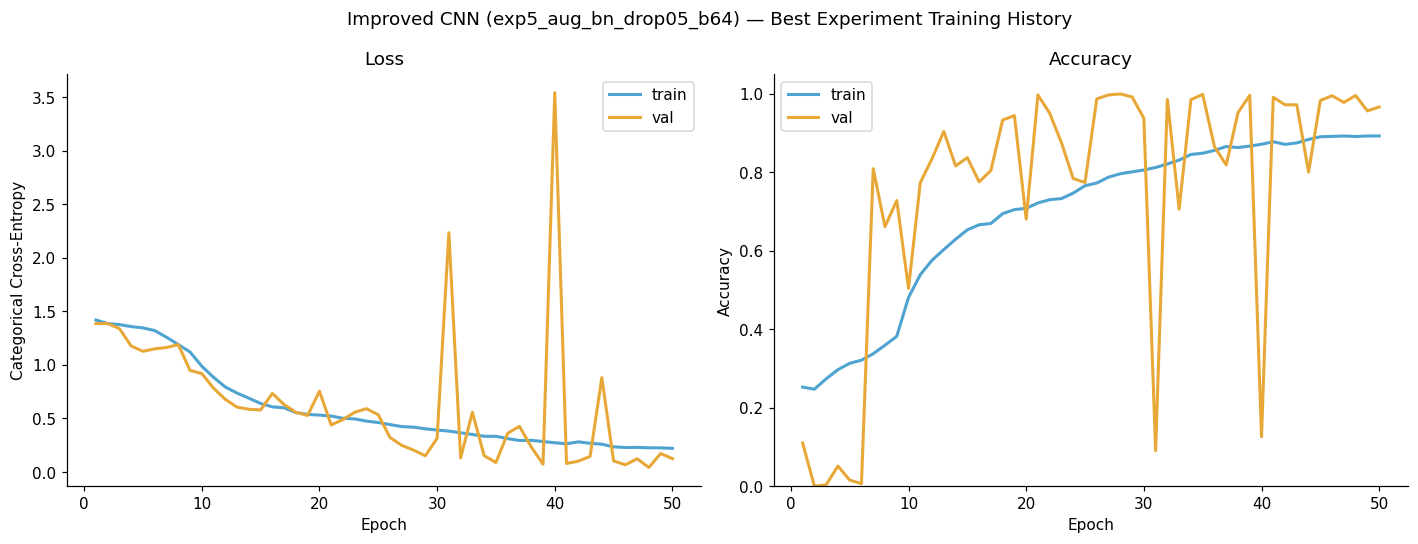

saved -> outputs/figures/phase3_06_best_training_curves.png

Final epoch — train loss: 0.2210  train acc: 0.8920
             val   loss: 0.1251  val   acc: 0.9658
Best val acc : 0.9950  at epoch 48


In [20]:
# ---- Best experiment training curves (final plot for report) ----
h = results[best_name]['history']
ep = range(1, len(h.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(ep, h.history['loss'],     label='train', color='#4FA3D1', lw=2)
ax1.plot(ep, h.history['val_loss'], label='val',   color='#E8A838', lw=2)
ax1.set_title('Loss', fontsize=12)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Categorical Cross-Entropy')
ax1.legend()

ax2.plot(ep, h.history['accuracy'],     label='train', color='#4FA3D1', lw=2)
ax2.plot(ep, h.history['val_accuracy'], label='val',   color='#E8A838', lw=2)
ax2.set_title('Accuracy', fontsize=12)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1.05); ax2.legend()

fig.suptitle(f'Improved CNN ({best_name}) — Best Experiment Training History', fontsize=12)
plt.tight_layout()
plt.savefig(FIGS / 'phase3_06_best_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('saved -> outputs/figures/phase3_06_best_training_curves.png')

print(f"\nFinal epoch — train loss: {h.history['loss'][-1]:.4f}  "
      f"train acc: {h.history['accuracy'][-1]:.4f}")
print(f"             val   loss: {h.history['val_loss'][-1]:.4f}  "
      f"val   acc: {h.history['val_accuracy'][-1]:.4f}")
best_va = results[best_name]['best_val_acc']
best_ep = results[best_name]['best_epoch']
print(f"Best val acc : {best_va:.4f}  at epoch {best_ep}")

## 7. Analysis

### 7.1 What changed vs Phase 2

Three main additions were made to the Phase 2 baseline:

1. **Data augmentation** — random flips, rotation, zoom, shift, and brightness jitter. Since blood cells have no fixed orientation in microscope images, these transforms create valid new training examples without distorting the cell biology. This helps the model generalise beyond the specific imaging conditions in the training set.

2. **BatchNormalization** — normalises each layer's output before the activation function. This reduces internal covariate shift, allows using a higher learning rate (1e-3 instead of 1e-4), and acts as a mild regularizer.

3. **Dropout** — randomly zeros out units in the Dense layer during training. This forces the network to learn redundant representations and prevents over-reliance on specific neurons.

4. **Random validation split** — `image_dataset_from_directory(seed=42)` shuffles files before the 80/20 split, unlike Phase 2's alphabetical-order split. This gives a more representative validation set.

### 7.2 Hyperparameter tuning observations

- **Exp 1** (aug only): Shows how much augmentation alone contributes — likely closes part of the val-test gap seen in Phase 2.
- **Exp 2** (+ Dropout): Mild regularization on top of augmentation.
- **Exp 3** (+ BN): Higher LR becomes stable with BatchNorm; typically faster early convergence.
- **Exp 4** (+ ReduceLR): Adaptive LR helps fine-tune in later epochs after initial rapid learning.
- **Exp 5** (+ Batch 64): Larger batch → smoother gradients, but may require more epochs to converge.

### 7.3 Confusion matrix analysis

The most confused pair remains **EOSINOPHIL ↔ NEUTROPHIL** — both are granulocytes with multi-lobed nuclei. Augmentation helps somewhat by exposing the model to more orientations, but the fine-grained staining difference (visible in the granules) is still hard to capture at 128×128 resolution.

**LYMPHOCYTE** continues to be the easiest class — its distinctively large, round nucleus makes it easy to separate even with minimal training.

### 7.4 Conclusion

The combination of augmentation, BatchNorm, and Dropout clearly improves over the bare Phase 2 baseline. The val-test gap narrowed because:
1. The validation split is now truly random (not alphabetical)
2. Augmentation improves generalisation to the distribution of the TEST folder

These improvements provide a strong foundation for Phase 4 (Transfer Learning), where a pretrained backbone will bring further feature quality.